# cool_maps engine quick check

Use this notebook to verify that the plotting helpers work with both the Cartopy and Basemap engines.

In [1]:
from pprint import pprint

import matplotlib.pyplot as plt

import cool_maps.plot as cplt

extent = (-78, -65, 35, 43)

print("Active engine:", cplt.get_engine())
print("Available engines:")
pprint(cplt.available_engines())

Active engine: cartopy
Available engines:
('cartopy', 'basemap')


In [2]:
def draw_map(engine, **create_kwargs):
    print(f"\n--- Drawing with engine: {engine} ---")
    # Pass engine= directly to create() rather than mutating the global engine as
    # a side effect -- the axes returned remembers its own engine, so downstream
    # calls (add_features, add_bathymetry, ...) never need engine= either.
    fig, ax = cplt.create(
        extent=extent,
        engine=engine,
        gridlines=True,
        bathymetry=False,
        features=True,
        **create_kwargs,
    )
    ax.set_title(f"{engine.title()} example")
    plt.show()
    # plt.close(fig)


def exercise_engine(engine):
    try:
        draw_map(engine)
    except Exception as exc:  # noqa: BLE001
        print(f"Engine '{engine}' raised an error:\n{exc}")


--- Drawing with engine: cartopy ---


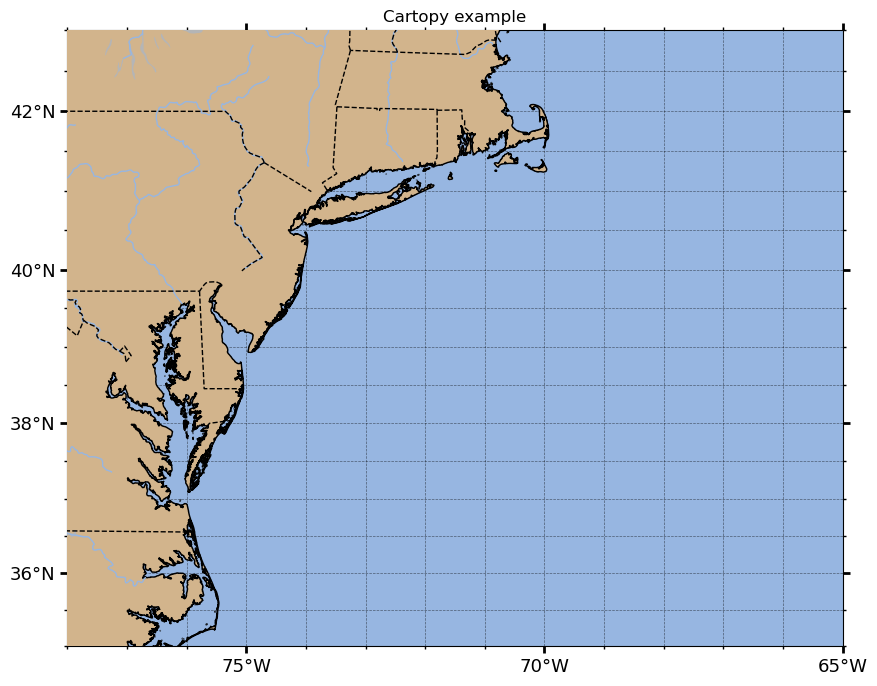

In [3]:
exercise_engine("cartopy")


--- Drawing with engine: basemap ---


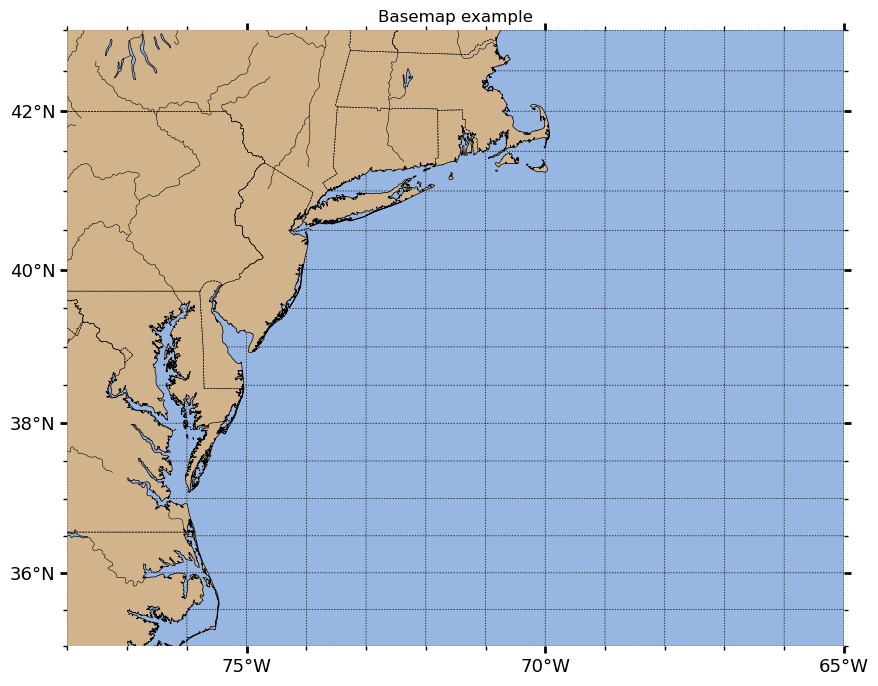

In [4]:
if "basemap" in cplt.available_engines():
    exercise_engine("basemap")
else:
    print("Basemap is not installed in this environment; skipping that engine.")

If both engines render without errors, the engine abstractions are functioning as expected.